### Differential Equations and Linear Algebra | Gilbert Strang | Solutions and Code by David A. Lee
### Chapter 8: Fourier and Laplace Transforms
#### Section 8.3: The Heat Equation 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MaxNLocator
import scienceplots

In [2]:
def style_ax3d(
    ax,
    xlabel='$x$',
    ylabel='$y$',
    zlabel='$z$',
    xlim=None,
    ylim=None,
    zlim=None,
    xticks=None,
    xticklabels=None,
    yticks=None,
    yticklabels=None,
    zticks=None,
    zticklabels=None,
    color='white',
    *,
    label_fontsize=16,
    tick_fontsize=None,
    fontsize=None,
):
    """Axis titles vs tick numbers can use different font sizes.

    Legacy: if only ``fontsize`` is given, it applies to labels and ticks.
    """
    if fontsize is not None:
        label_fontsize = fontsize
        if tick_fontsize is None:
            tick_fontsize = fontsize
    if tick_fontsize is None:
        tick_fontsize = label_fontsize

    ax.set_xlabel(xlabel, color=color, fontsize=label_fontsize, labelpad=6)
    ax.set_ylabel(ylabel, color=color, fontsize=label_fontsize, labelpad=6)
    ax.set_zlabel(zlabel, color=color, fontsize=label_fontsize, labelpad=6)
    ax.tick_params(colors=color, labelsize=tick_fontsize)
    ax.minorticks_off()
    ax.grid(False)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    if zlim is not None:
        ax.set_zlim(zlim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels, color=color)
    if yticks is not None:
        ax.set_yticks(yticks)
    if yticklabels is not None:
        ax.set_yticklabels(yticklabels, color=color)
    if zticks is not None:
        ax.set_zticks(zticks)
    if zticklabels is not None:
        ax.set_zticklabels(zticklabels, color=color)
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(color)
    ax.yaxis.pane.set_edgecolor(color)
    ax.zaxis.pane.set_edgecolor(color)

Question 8.3.2

# Can we draw an arrow to indicate direction of time?

C:\Users\david\AppData\Local\Temp\ipykernel_26328\3299900764.py:9: RuntimeWarning: divide by zero encountered in divide
  U = (1/np.sqrt(4*np.pi*c*t))*np.exp(-x**2 / (4*c*t))
C:\Users\david\AppData\Local\Temp\ipykernel_26328\3299900764.py:9: RuntimeWarning: invalid value encountered in multiply
  U = (1/np.sqrt(4*np.pi*c*t))*np.exp(-x**2 / (4*c*t))


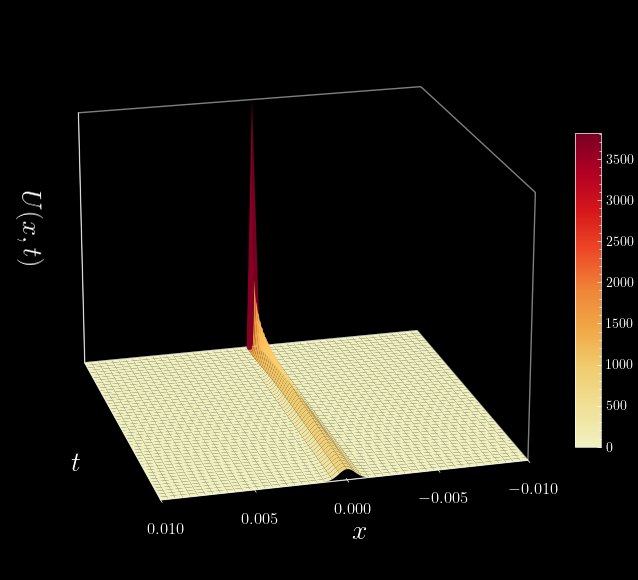

In [15]:
#%matplotlib inline
x_min, x_max = -0.01, 0.01
t_min, t_max = 0, 0.01
nx, nt = 1000, 1000  # grid resolution

c = 1e-5 # approximate thermal diffusivity of liquids

def U(x, t):
    U = (1/np.sqrt(4*np.pi*c*t))*np.exp(-x**2 / (4*c*t))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

# Optional: z-axis limits (set to None to auto-scale from Z)
u_min, u_max = float(np.nanmin(u)), float(np.nanmax(u))

plt.style.use(['science', 'scatter', 'dark_background'])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

# choose where ticks go (example: 5 ticks along x)
ax.set_xticks(np.linspace(x_min, x_max, 5))
# optional: visible tick lines (if you zeroed length before)
ax.tick_params(axis='x', length=4, width=0.8)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap='YlOrRd', linewidth=0, antialiased=True, alpha=0.95
)

# Your style_ax3d(...) here — same ax as above
style_ax3d(
    ax, xlabel='$x$', ylabel='$t$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

# View orientation
ax.view_init(elev=20, azim=75)   # common default-ish view

plt.tight_layout()
fig.savefig("chap8sec8.3ex2.pdf", format="pdf")
plt.show()

Question 8.3.4

C:\Users\david\AppData\Local\Temp\ipykernel_26328\3544489302.py:9: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  U = 1/2 + np.sum(np.exp(-c*(2*k-1)**2*np.pi**2*t)*((2/np.pi)*((-1)**k)/(2*k-1))*np.cos((4*k-2)*np.pi*x) for k in range(1, 100))


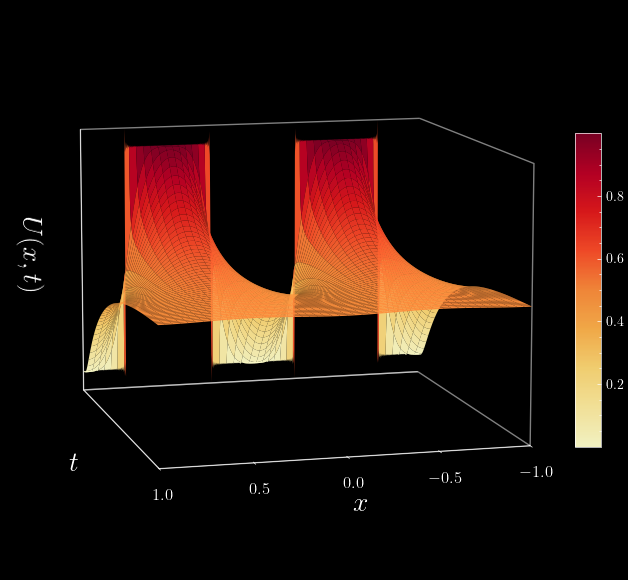

In [16]:
# %matplotlib widget
x_min, x_max = -1, 1
t_min, t_max = 0, 0.5
nx, nt = 1000, 1000  # grid resolution

c = 1

def U(x, t):
    U = 1/2 + np.sum(np.exp(-c*(2*k-1)**2*np.pi**2*t)*((2/np.pi)*((-1)**k)/(2*k-1))*np.cos((4*k-2)*np.pi*x) for k in range(1, 100))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

# Optional: z-axis limits (set to None to auto-scale from Z)
u_min, u_max = float(np.nanmin(u)), float(np.nanmax(u))

plt.style.use(['science', 'scatter', 'dark_background'])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

# choose where ticks go (example: 5 ticks along x)
ax.set_xticks(np.linspace(x_min, x_max, 5))
# optional: visible tick lines (if you zeroed length before)
ax.tick_params(axis='x', length=4, width=0.8)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap='YlOrRd', linewidth=0, antialiased=True, alpha=0.95
)

# Your style_ax3d(...) here — same ax as above
style_ax3d(
    ax, xlabel='$x$', ylabel='$t$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

# View orientation
ax.view_init(elev=10, azim=75)   # common default-ish view

plt.tight_layout()
fig.savefig("chap8sec8.3ex4.pdf", format="pdf")
plt.show()

Question 8.3.5

C:\Users\david\AppData\Local\Temp\ipykernel_26328\4115623668.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  U = 1/(2*np.pi) + (1/np.pi)*np.sum(np.exp(-k**2*np.pi**2*t)*np.cos(k*x) for k in range(1, 100))
C:\Users\david\AppData\Local\Temp\ipykernel_26328\4115623668.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


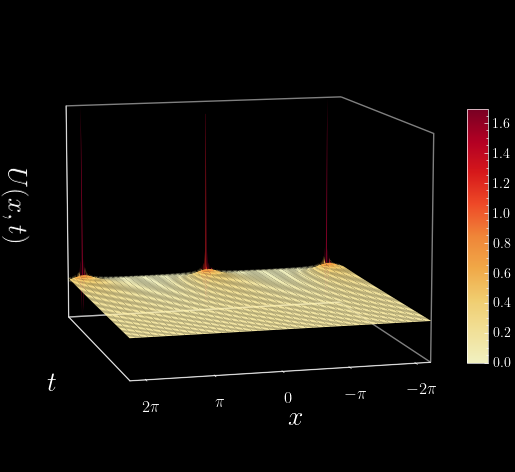

In [22]:
# %matplotlib widget
x_min, x_max = -7, 7
t_min, t_max = 0, 0.5
nx, nt = 1000, 1000  # grid resolution

def U(x, t):
    U = 1/(2*np.pi) + (1/np.pi)*np.sum(np.exp(-k**2*np.pi**2*t)*np.cos(k*x) for k in range(1, 100))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

# Optional: z-axis limits (set to None to auto-scale from Z)
u_min, u_max = float(np.nanmin(u)), float(np.nanmax(u))

plt.style.use(['science', 'scatter', 'dark_background'])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

xticks = np.array([-2, -1, 0, 1, 2]) * np.pi
xticklabels = [r'$-2\pi$', r'$-\pi$', '0', r'$\pi$', r'$2\pi$']

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap='YlOrRd', linewidth=0, antialiased=True, alpha=0.95
)

# Your style_ax3d(...) here — same ax as above
style_ax3d(
    ax, xlabel='$x$', ylabel='$t$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

# View orientation
ax.view_init(elev=10, azim=75)   # common default-ish view

plt.tight_layout()
fig.savefig("chap8sec8.3ex5.pdf", format="pdf")
plt.show()

Question 8.3.6

C:\Users\david\AppData\Local\Temp\ipykernel_33832\2216851936.py:9: RuntimeWarning: divide by zero encountered in divide
  U = (1 / np.sqrt(4*np.pi*t))*(np.exp(-(x - a)**2 / (4*t)) - np.exp(-(x + a)**2 / (4*t)))
C:\Users\david\AppData\Local\Temp\ipykernel_33832\2216851936.py:9: RuntimeWarning: invalid value encountered in multiply
  U = (1 / np.sqrt(4*np.pi*t))*(np.exp(-(x - a)**2 / (4*t)) - np.exp(-(x + a)**2 / (4*t)))


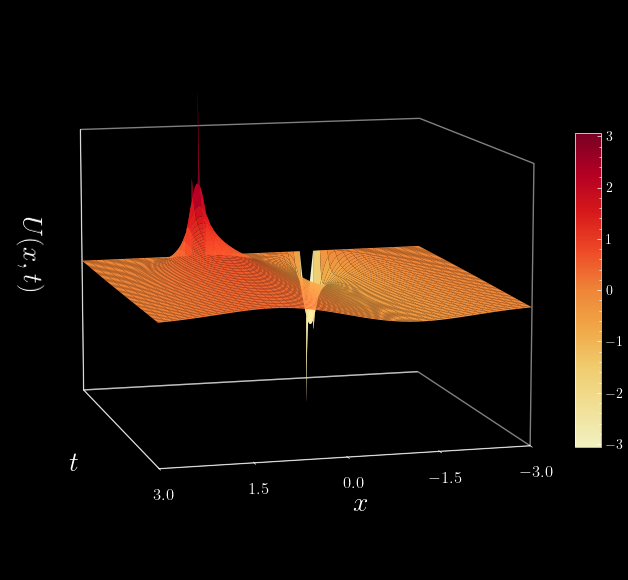

In [5]:
# %matplotlib widget
x_min, x_max = -3, 3
t_min, t_max = 0, 0.5
nx, nt = 2500, 2500  # grid resolution

a = 1

def U(x, t):
    U = (1 / np.sqrt(4*np.pi*t))*(np.exp(-(x - a)**2 / (4*t)) - np.exp(-(x + a)**2 / (4*t)))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

# Optional: z-axis limits (set to None to auto-scale from Z)
u_min, u_max = float(np.nanmin(u)) / 4, float(np.nanmax(u)) / 4

plt.style.use(['science', 'scatter', 'dark_background'])

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

# choose where ticks go (example: 5 ticks along x)
ax.set_xticks(np.linspace(x_min, x_max, 5))
# optional: visible tick lines (if you zeroed length before)
ax.tick_params(axis='x', length=4, width=0.8)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap='YlOrRd', linewidth=0, antialiased=True, alpha=0.95
)

# Your style_ax3d(...) here — same ax as above
style_ax3d(
    ax, xlabel='$x$', ylabel='$t$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

# View orientation
ax.view_init(elev=10, azim=75)   # common default-ish view

plt.tight_layout()
fig.savefig("chap8sec8.3ex6.pdf", format="pdf")
plt.show()

In [29]:
u_min

-19.94312419824553